# Load the dataset

In [1]:
import pandas as pd
df = pd.read_csv("obesity-dataset.csv")

In [2]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# Shape of the original dataset

In [3]:
df.shape

(2111, 17)

# Number of duplicate rows

In [4]:
df.duplicated().sum()

21

# Remove duplicate rows

In [5]:
df = df.drop_duplicates()

In [6]:
df.shape

(2090, 17)

# Data type of each column

In [7]:
df.dtypes

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

# Categories of the "Gender" column

In [8]:
df["Gender"].value_counts()

Gender
Male      1054
Female    1036
Name: count, dtype: int64

# Categories of the "family_history_with_overweight" column

In [9]:
df["family_history_with_overweight"].value_counts()

family_history_with_overweight
yes    1722
no      368
Name: count, dtype: int64

# Categories of the "FAVC" column

In [10]:
df["FAVC"].value_counts()

FAVC
yes    1847
no      243
Name: count, dtype: int64

# Categories of the "SMOKE" column

In [11]:
df["SMOKE"].value_counts()

SMOKE
no     2046
yes      44
Name: count, dtype: int64

# Categories of the "SCC" column

In [12]:
df["SCC"].value_counts()

SCC
no     1994
yes      96
Name: count, dtype: int64

# Label encoding "Gender", "family_history_with_overweight", "FAVC", "SMOKE" and "SCC" columns

In [13]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
cols_to_encode = ["Gender", "family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Categories of the "CAEC" column

In [14]:
df["CAEC"].value_counts()

CAEC
Sometimes     1761
Frequently     237
Always          53
no              39
Name: count, dtype: int64

# Categories of the "CALC" column  

In [15]:
df["CALC"].value_counts()

CALC
Sometimes     1383
no             636
Frequently      70
Always           1
Name: count, dtype: int64

# Manual encoding "CAEC" and "CALC" columns

In [16]:
frequency_mapping = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}

for col in ['CAEC', 'CALC']:
    df[col] = df[col].map(frequency_mapping)

# One-hot encoding the "MTRANS" column

In [17]:
df["MTRANS"].value_counts()

MTRANS
Public_Transportation    1561
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64

In [18]:
df = pd.get_dummies(df, columns=['MTRANS'], dtype=int)

# Manual encoding the "NObeyesdad" column

In [19]:
df["NObeyesdad"].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     278
Insufficient_Weight    268
Name: count, dtype: int64

In [20]:
NObeyesdad_mapping = {
    "Obesity_Type_I": 0,
    "Obesity_Type_III": 1,
    "Obesity_Type_II": 2,
    "Overweight_Level_II": 3,
    "Normal_Weight": 4,
    "Overweight_Level_I": 5,
    "Insufficient_Weight": 6
}
df['NObeyesdad'] = df['NObeyesdad'].map(NObeyesdad_mapping)

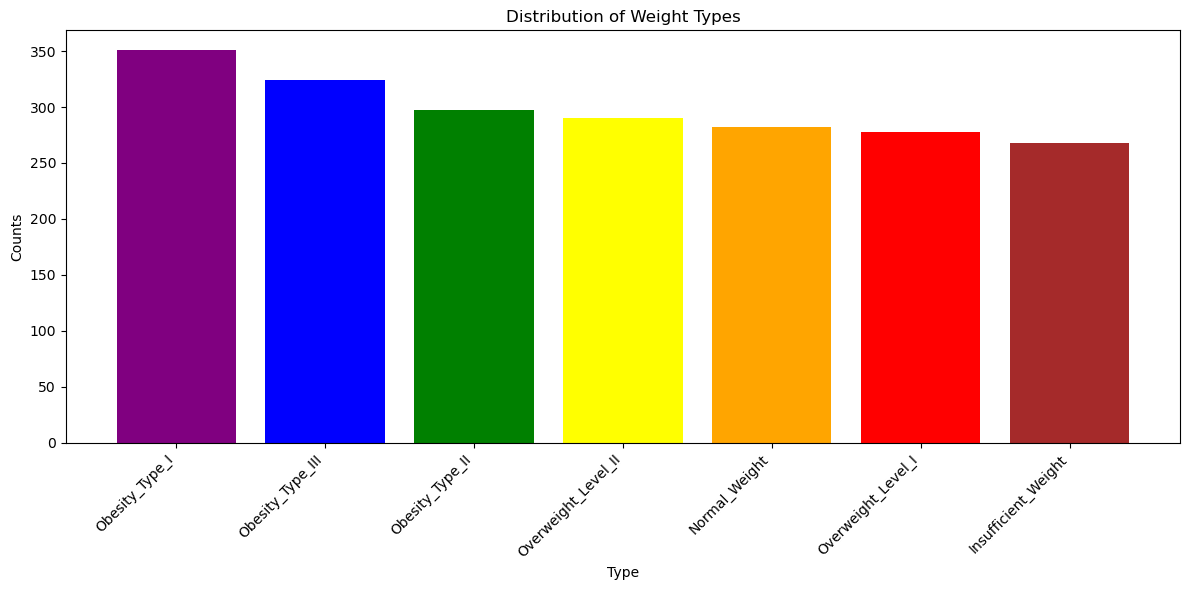

In [21]:
import matplotlib.pyplot as plt

types = [
    "Obesity_Type_I",
    "Obesity_Type_III",
    "Obesity_Type_II",
    "Overweight_Level_II",
    "Normal_Weight",
    "Overweight_Level_I",
    "Insufficient_Weight"
]

counts = [351, 324, 297, 290, 282, 278, 268]

plt.figure(figsize=(12, 6))
plt.bar(types, counts, color=["purple", "blue", "green", "yellow", "orange", "red", "brown"])
plt.xlabel("Type")
plt.ylabel("Counts")
plt.title("Distribution of Weight Types")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Final data type of each column

In [22]:
df.dtypes

Gender                              int32
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight      int32
FAVC                                int32
FCVC                              float64
NCP                               float64
CAEC                                int64
SMOKE                               int32
CH2O                              float64
SCC                                 int32
FAF                               float64
TUE                               float64
CALC                                int64
NObeyesdad                          int64
MTRANS_Automobile                   int32
MTRANS_Bike                         int32
MTRANS_Motorbike                    int32
MTRANS_Public_Transportation        int32
MTRANS_Walking                      int32
dtype: object

# Count of NULL values for each column

In [23]:
df.isnull().sum()

Gender                             0
Age                               30
Height                            45
Weight                            55
family_history_with_overweight     0
FAVC                               0
FCVC                              40
NCP                                0
CAEC                               0
SMOKE                              0
CH2O                               0
SCC                                0
FAF                               60
TUE                                0
CALC                               0
NObeyesdad                         0
MTRANS_Automobile                  0
MTRANS_Bike                        0
MTRANS_Motorbike                   0
MTRANS_Public_Transportation       0
MTRANS_Walking                     0
dtype: int64

# Define input and target variables

In [24]:
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

# Split the data

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the KNN Imputer

In [26]:
from sklearn.impute import KNNImputer
import pandas as pd

knn_imputer = KNNImputer(n_neighbors=5)

# Fit and Transform the training data

In [27]:
X_train_imputed = knn_imputer.fit_transform(X_train)

# Transform the test data

In [28]:
X_test_imputed = knn_imputer.transform(X_test)

# Convert imputed data back to data frames

In [29]:
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)

# Final NULL value check for the input variables

In [30]:
X_train_imputed.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS_Automobile                 0
MTRANS_Bike                       0
MTRANS_Motorbike                  0
MTRANS_Public_Transportation      0
MTRANS_Walking                    0
dtype: int64

In [31]:
X_test_imputed.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS_Automobile                 0
MTRANS_Bike                       0
MTRANS_Motorbike                  0
MTRANS_Public_Transportation      0
MTRANS_Walking                    0
dtype: int64

In [32]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,...,0,0.0,1.0,0,4,0,0,0,1,0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,...,1,3.0,0.0,1,4,0,0,0,1,0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,...,0,2.0,1.0,2,4,0,0,0,1,0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,...,0,2.0,0.0,2,5,0,0,0,0,1
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,...,0,0.0,0.0,1,3,0,0,0,1,0


# Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Cross-Validation

In [34]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

svm_model = SVC()

scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(f"SVM: Mean Accuracy: {scores.mean():.3f}")

SVM: Mean Accuracy: 0.850


# Hypeparameter Tuning for the SVC model

In [35]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

svm = SVC(random_state=42)

param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto", 0.1, 1]
}

grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV accuracy: 0.9401930467423361


# Final Model Evaluation

In [36]:
from sklearn.metrics import accuracy_score, classification_report

best_svm = grid.best_estimator_

y_pred = best_svm.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {final_accuracy:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Final Test Accuracy: 0.938

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        70
           1       0.98      1.00      0.99        65
           2       0.98      0.97      0.97        59
           3       0.92      0.93      0.92        58
           4       0.89      0.84      0.86        56
           5       0.88      0.88      0.88        56
           6       0.98      0.96      0.97        54

    accuracy                           0.94       418
   macro avg       0.94      0.94      0.94       418
weighted avg       0.94      0.94      0.94       418



# Heatmap of the final output predictions

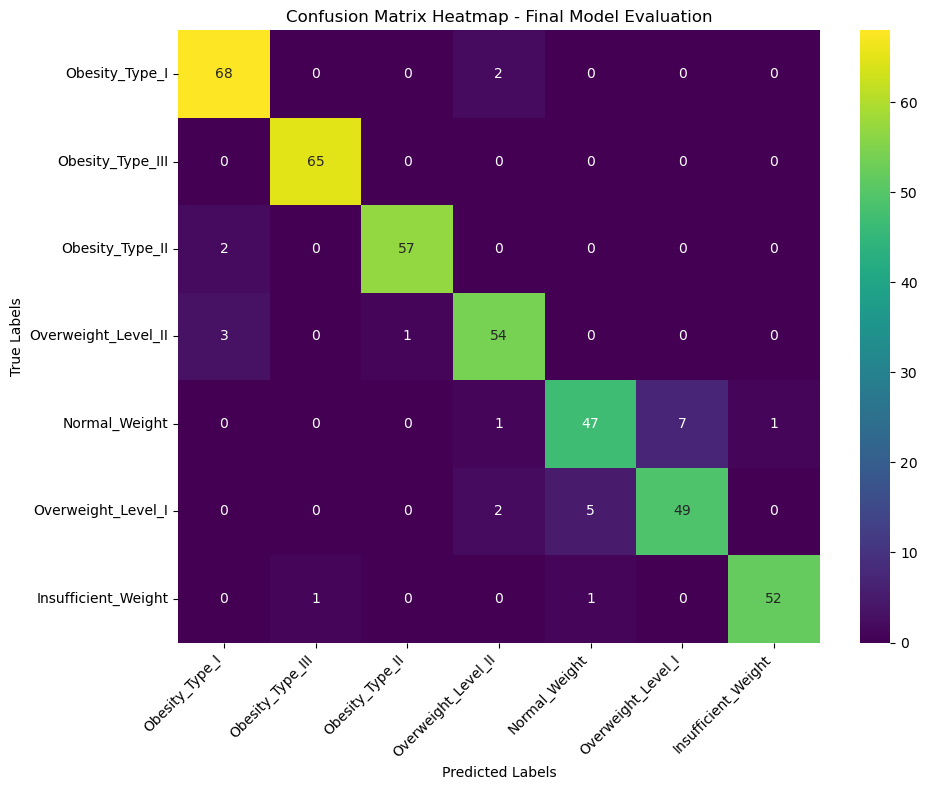

In [37]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

labels = [
    "Obesity_Type_I", 
    "Obesity_Type_III", 
    "Obesity_Type_II", 
    "Overweight_Level_II", 
    "Normal_Weight", 
    "Overweight_Level_I", 
    "Insufficient_Weight"
]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix Heatmap - Final Model Evaluation')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Save the model

In [38]:
import joblib

model_assets = {
    "model": best_svm,          
    "scaler": scaler,         
    "imputer": knn_imputer,    
    "label_encoders": encoders   
}

joblib.dump(model_assets, 'obesity_full_pipeline.joblib')

print("Success! Model, Scaler, Imputer, and Encoders saved to 'obesity_full_pipeline.joblib'")

Success! Model, Scaler, Imputer, and Encoders saved to 'obesity_full_pipeline.joblib'
